In [1]:
%load_ext autoreload
%autoreload 

# Set LD_LIBRARY_PATH for cuequivariance_ops
import os, ctypes
from glob import glob
# append_ld_library_path = "~/.local/lib/python3.10/site-packages/nvidia/cublas/lib"
# LD_LIBRARY_PATH = os.environ.get("LD_LIBRARY_PATH", "")
# os.environ["LD_LIBRARY_PATH"] = f"{append_ld_library_path}:{LD_LIBRARY_PATH}" if LD_LIBRARY_PATH else append_ld_library_path

# cublas_dir = "/home/ubuntu/.local/lib/python3.10/site-packages/nvidia/cublas/lib"
# for pat in ["libcublas.so*", "libcublasLt.so*", "libcudart.so*"]:
#     for lib in sorted(glob(os.path.join(cublas_dir, pat))):
#         try:
#             ctypes.CDLL(lib, mode=ctypes.RTLD_GLOBAL)
#         except OSError as e:
#             print(f"Warning: could not load {lib}: {e}")

import torch
import torch._dynamo
torch._dynamo.config.suppress_errors = True

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
import pickle
from tqdm import tqdm
from glob import glob
from copy import deepcopy
import itertools

import esm

from MSA_Pairformer.model import MSAPairformer
from MSA_Pairformer.dataset import aa2tok_d, prepare_msa_masks, MSA
from MSA_Pairformer.utils import evaluate_contact_prediction
from MSA_Pairformer.categorical_jacobian import get_coevolution
from MSA_Pairformer.plotting import plot_contact_map

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
torch.set_float32_matmul_precision('high')
print(f"Using device: {torch.cuda.get_device_name(device)}")

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
Error while loading libcue_ops.so: /home/ubuntu/.local/lib/python3.10/site-packages/cuequivariance_ops/lib/libcue_ops.so: undefined symbol: cublasGemmGroupedBatchedEx, version libcublas.so.12


Using device: NVIDIA GH200 480GB


In [2]:
# Load target data
target_data_file = "../../data/Figure5_CASP_ProteinGym/target_data.pkl"
with open(target_data_file, "rb") as oFile:
    target_data_d = pickle.load(oFile)

# 1. MSA Pairformer

In [8]:
# Load model
model = MSAPairformer.from_pretrained(device=device)
model.eval()

# Count number of parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Using cuEquivariance for triangle multiplicative update
Total parameters: 111,365,468
Trainable parameters: 111,365,468


## 1.1 UniRef sequences only

In [11]:
nSeqs = 512
all_results_d = {}
# Iterate over all targets
for target_id in tqdm(target_data_d):
    # Load MSA
    msa_file = target_data_d[target_id]["uniref_msa_file"]
    with open(msa_file, "r") as oFile:
        query_seq = oFile.readlines()[1].strip()
    if len(query_seq) > 2048:
        print(f"Skipping {target_id} because it has more than 2048 tokens...rerun with half precision: {target_id}")
        continue
    np.random.seed(42)
    msa_obj = MSA(
        msa_file_path = msa_file,
        max_seqs=nSeqs,
        max_length=len(query_seq),
        max_tokens=1e12,
        diverse_select_method="greedy",
    )
    msa_tokenized_t = msa_obj.diverse_tokenized_msa
    msa_onehot_t = torch.nn.functional.one_hot(msa_obj.diverse_tokenized_msa, num_classes=len(aa2tok_d)).unsqueeze(0)
    msa_onehot_t = msa_onehot_t.float().to(device)
    mask, msa_mask, full_mask, pairwise_mask = prepare_msa_masks(msa_obj.diverse_tokenized_msa.unsqueeze(0))
    mask, msa_mask, full_mask, pairwise_mask = mask.to(device), msa_mask.to(device), full_mask.to(device), pairwise_mask.to(device)

    # Run model prediction
    with torch.no_grad():
        model.turn_off_query_biasing()
        uniform_res = model(
            msa = msa_onehot_t,
            mask = mask,
            msa_mask = msa_mask,
            full_mask = full_mask,
            pairwise_mask = pairwise_mask,
        )
        uniform_contacts_a = uniform_res['predicted_cb_contacts'][0].cpu().numpy()
        model.turn_on_query_biasing()
        qba_res = model(
            msa = msa_onehot_t,
            mask = mask,
            msa_mask = msa_mask,
            full_mask = full_mask,
            pairwise_mask = pairwise_mask,
            return_seq_weights = True,
        )
        qba_contacts_a = qba_res['predicted_cb_contacts'][0].cpu().numpy()
        
    # Load contacts
    contacts_a = target_data_d[target_id]["contacts_a"]
    # Mask for valid positions
    valid_mask = contacts_a >= 0
    contacts_a[~valid_mask] = 0
    # Subset predicted contact maps for overlapping residues
    msa_subset_idx_l = target_data_d[target_id]["msa_subset_idx_l"]
    subset_uniform_contacts_a = deepcopy(uniform_contacts_a[msa_subset_idx_l, :][:, msa_subset_idx_l])
    subset_qba_contacts_a = deepcopy(qba_contacts_a[msa_subset_idx_l, :][:, msa_subset_idx_l])
    subset_uniform_contacts_a[~valid_mask] = 0
    subset_qba_contacts_a[~valid_mask] = 0
    uniform_eval_d = evaluate_contact_prediction(torch.from_numpy(subset_uniform_contacts_a), torch.from_numpy(contacts_a))
    qba_eval_d = evaluate_contact_prediction(torch.from_numpy(subset_qba_contacts_a), torch.from_numpy(contacts_a))
    
    # Aggregate results
    all_results_d[target_id] = {
        "uniform_eval_d": uniform_eval_d,
        "qba_eval_d": qba_eval_d,
        "full_uniform_contacts_a": uniform_contacts_a,
        "full_qba_contacts_a": qba_contacts_a,
        "monomer_uniform_contacts_a": subset_uniform_contacts_a,
        "monomer_qba_contacts_a": subset_qba_contacts_a,
        "qba_sequence_weights": np.stack([qba_res['seq_weights_list_d'][layer][0].cpu().numpy() for layer in qba_res['seq_weights_list_d']])
    }

with open(f"results/msa_pairformer/all_results.hhblits_uniref.pkl", "wb") as oFile:
    pickle.dump(all_results_d, oFile)

contact_eval_categories_l = list(all_results_d[list(all_results_d.keys())[0]]['uniform_eval_d'].keys())
results_df = pd.DataFrame(
    index = all_results_d.keys(),
    columns = ["uniform_" + cat for cat in contact_eval_categories_l] + ["qba_" + cat for cat in contact_eval_categories_l] + ["ho_qba_" + cat for cat in contact_eval_categories_l]
)
for target_id in all_results_d:
    for cat in contact_eval_categories_l:
        results_df.loc[target_id, "uniform_" + cat] = all_results_d[target_id]['uniform_eval_d'][cat]
        results_df.loc[target_id, "qba_" + cat] = all_results_d[target_id]['qba_eval_d'][cat]
results_df.to_csv(f"results/msa_pairformer/all_results.hhblits_uniref.tsv", sep="\t")

 47%|████▋     | 23/49 [00:30<00:43,  1.68s/it]

Skipping T1169 because it has more than 2048 tokens...rerun with half precision: T1169


100%|██████████| 49/49 [01:00<00:00,  1.23s/it]


## 1.2 UniRef + Logan sequences

In [14]:
nSeqs = 512
all_results_d = {}
# Iterate over all targets
for target_id in tqdm(target_data_d):
    # Load MSA
    msa_file = target_data_d[target_id]["logan_msa_file"]
    with open(msa_file, "r") as oFile:
        query_seq = oFile.readlines()[1].strip()
    if len(query_seq) > 2048:
        print(f"Skipping {target_id} because it has more than 2048 tokens...rerun with half precision: {target_id}")
        continue
    np.random.seed(42)
    msa_obj = MSA(
        msa_file_path = msa_file,
        max_seqs=nSeqs,
        max_length=len(query_seq),
        max_tokens=1e12,
        diverse_select_method="greedy",
    )
    msa_tokenized_t = msa_obj.diverse_tokenized_msa
    msa_onehot_t = torch.nn.functional.one_hot(msa_obj.diverse_tokenized_msa, num_classes=len(aa2tok_d)).unsqueeze(0)
    msa_onehot_t = msa_onehot_t.float().to(device)
    mask, msa_mask, full_mask, pairwise_mask = prepare_msa_masks(msa_obj.diverse_tokenized_msa.unsqueeze(0))
    mask, msa_mask, full_mask, pairwise_mask = mask.to(device), msa_mask.to(device), full_mask.to(device), pairwise_mask.to(device)

    # Run model prediction
    with torch.no_grad():
        model.turn_off_query_biasing()
        uniform_res = model(
            msa = msa_onehot_t,
            mask = mask,
            msa_mask = msa_mask,
            full_mask = full_mask,
            pairwise_mask = pairwise_mask,
        )
        uniform_contacts_a = uniform_res['predicted_cb_contacts'][0].cpu().numpy()
        model.turn_on_query_biasing()
        qba_res = model(
            msa = msa_onehot_t,
            mask = mask,
            msa_mask = msa_mask,
            full_mask = full_mask,
            pairwise_mask = pairwise_mask,
            return_seq_weights = True,
        )
        qba_contacts_a = qba_res['predicted_cb_contacts'][0].cpu().numpy()
        
    # Load contacts
    contacts_a = target_data_d[target_id]["contacts_a"]
    # Mask for valid positions
    valid_mask = contacts_a >= 0
    contacts_a[~valid_mask] = 0
    # Subset predicted contact maps for overlapping residues
    msa_subset_idx_l = target_data_d[target_id]["msa_subset_idx_l"]
    subset_uniform_contacts_a = deepcopy(uniform_contacts_a[msa_subset_idx_l, :][:, msa_subset_idx_l])
    subset_qba_contacts_a = deepcopy(qba_contacts_a[msa_subset_idx_l, :][:, msa_subset_idx_l])
    subset_uniform_contacts_a[~valid_mask] = 0
    subset_qba_contacts_a[~valid_mask] = 0
    uniform_eval_d = evaluate_contact_prediction(torch.from_numpy(subset_uniform_contacts_a), torch.from_numpy(contacts_a))
    qba_eval_d = evaluate_contact_prediction(torch.from_numpy(subset_qba_contacts_a), torch.from_numpy(contacts_a))
    
    # Aggregate results
    all_results_d[target_id] = {
        "uniform_eval_d": uniform_eval_d,
        "qba_eval_d": qba_eval_d,
        "full_uniform_contacts_a": uniform_contacts_a,
        "full_qba_contacts_a": qba_contacts_a,
        "monomer_uniform_contacts_a": subset_uniform_contacts_a,
        "monomer_qba_contacts_a": subset_qba_contacts_a,
        "qba_sequence_weights": np.stack([qba_res['seq_weights_list_d'][layer][0].cpu().numpy() for layer in qba_res['seq_weights_list_d']])
    }

with open(f"results/msa_pairformer_logan/all_results.hhblits_uniref_mmseqs_logan.pkl", "wb") as oFile:
    pickle.dump(all_results_d, oFile)

contact_eval_categories_l = list(all_results_d[list(all_results_d.keys())[0]]['uniform_eval_d'].keys())
results_df = pd.DataFrame(
    index = all_results_d.keys(),
    columns = ["uniform_" + cat for cat in contact_eval_categories_l] + ["qba_" + cat for cat in contact_eval_categories_l] + ["ho_qba_" + cat for cat in contact_eval_categories_l]
)
for target_id in all_results_d:
    for cat in contact_eval_categories_l:
        results_df.loc[target_id, "uniform_" + cat] = all_results_d[target_id]['uniform_eval_d'][cat]
        results_df.loc[target_id, "qba_" + cat] = all_results_d[target_id]['qba_eval_d'][cat]
results_df.to_csv(f"results/msa_pairformer_logan/all_results.hhblits_uniref_mmseqs_logan.tsv", sep="\t")

 47%|████▋     | 23/49 [00:35<00:45,  1.75s/it]

Skipping T1169 because it has more than 2048 tokens...rerun with half precision: T1169


100%|██████████| 49/49 [01:11<00:00,  1.46s/it]


# 2. MSA Transformer

## 2.1 UniRef sequences only

In [3]:
# Load model
model_path = "../../../esm_models/esm_msa1b_t12_100M_UR50S.pt"
msa_transformer, msa_transformer_alphabet = esm.pretrained.load_model_and_alphabet_local(model_path)
msa_transformer = msa_transformer.eval().to(torch.float16).cuda()
msa_transformer_batch_converter = msa_transformer_alphabet.get_batch_converter()
total_params = sum(p.numel() for p in msa_transformer.parameters())
print(f"Total number of parameters: {total_params:,}")

/home/ubuntu/.local/lib/python3.10/site-packages/esm/pretrained.py:70: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_data = torch.load(str(model_location), map_locatio

Total number of parameters: 115,616,434


In [5]:
all_results_d = {}
results_dir = "results/msa_transformer/"
nSeqs = 512
max_tokens = 512 * 384

for target_id in tqdm(target_data_d):
    # Load MSA
    msa_file = target_data_d[target_id]["uniref_msa_file"]
    with open(msa_file, "r") as oFile:
        query_seq = oFile.readlines()[1].strip()
    if len(query_seq) > 1024:
        print(f"Skipping {target_id} because it has more than 1024 tokens...cannot run MSA Transformer: {target_id}")
        continue
    np.random.seed(42)
    msa_obj = MSA(
        msa_file_path = msa_file,
        max_seqs=nSeqs,
        max_length=len(query_seq),
        max_tokens=1e12,
        diverse_select_method="greedy"
    )
    msa_obj = MSA(msa_file_path = msa_file, max_seqs=nSeqs, max_length=len(query_seq), max_tokens=max_tokens, diverse_select_method="greedy")
    msa_seq_l = [(seq_idx, "".join(seq)) for seq_idx, seq in enumerate(msa_obj.select_diverse_msa)]
    # Randomly select msa_obj.subset_depth sequences if necessary
    if msa_obj.subset_depth < len(msa_seq_l):
        random_seq_idxs = np.random.choice(range(1, len(msa_seq_l)), size=msa_obj.subset_depth-1, replace=False)
        msa_seq_l = [msa_seq_l[0]] + [msa_seq_l[i] for i in random_seq_idxs]
    # Prep MSA Transformer inputs
    batch_labels, batch_strs, batch_tokens = msa_transformer_batch_converter([msa_seq_l])
    batch_tokens = batch_tokens.to(device)
    # Predict contacts
    with torch.no_grad():
        predicted_contacts_a = msa_transformer.predict_contacts(batch_tokens)[0].cpu().numpy()

    # Load contacts
    contacts_a = target_data_d[target_id]["contacts_a"]
    # Mask for valid positions
    valid_mask = contacts_a >= 0
    contacts_a[~valid_mask] = 0
    # Subset predicted contact maps for overlapping residues
    msa_subset_idx_l = target_data_d[target_id]["msa_subset_idx_l"]
    subset_contacts_a = deepcopy(predicted_contacts_a[msa_subset_idx_l, :][:, msa_subset_idx_l])
    subset_contacts_a[~valid_mask] = 0
    eval_d = evaluate_contact_prediction(torch.from_numpy(subset_contacts_a), torch.from_numpy(contacts_a))
    
    # Aggregate results
    all_results_d[target_id] = {
        "eval_d": eval_d,
        "full_contacts_a": predicted_contacts_a,
        "monomer_contacts_a": subset_contacts_a,
    }
results_path = os.path.join(results_dir, f"msa_transformer_results.pkl")
with open(results_path, "wb") as oFile:
    pickle.dump(all_results_d, oFile)
contact_eval_categories_l = list(all_results_d[list(all_results_d.keys())[0]]['eval_d'].keys())
results_df = pd.DataFrame(
    index = all_results_d.keys(),
    columns = contact_eval_categories_l
)
for target_id in all_results_d:
    for cat in contact_eval_categories_l:
        results_df.loc[target_id, cat] = all_results_d[target_id]['eval_d'][cat]
results_df.to_csv(f"results/msa_transformer/msa_transformer_results.tsv", sep="\t")


 37%|███▋      | 18/49 [00:14<00:28,  1.07it/s]

Skipping T1158 because it has more than 1024 tokens...cannot run MSA Transformer: T1158


 47%|████▋     | 23/49 [00:16<00:13,  1.93it/s]

Skipping T1169 because it has more than 1024 tokens...cannot run MSA Transformer: T1169


 63%|██████▎   | 31/49 [00:22<00:14,  1.26it/s]

Skipping T1125 because it has more than 1024 tokens...cannot run MSA Transformer: T1125


 90%|████████▉ | 44/49 [00:29<00:02,  1.98it/s]

Skipping T1154 because it has more than 1024 tokens...cannot run MSA Transformer: T1154


100%|██████████| 49/49 [00:37<00:00,  1.30it/s]


## 2.2 Logan + UniRef sequences

In [6]:
all_results_d = {}
results_dir = "results/msa_transformer_logan/"
nSeqs = 512
max_tokens = 512 * 384

for target_id in tqdm(target_data_d):
    # Load MSA
    msa_file = target_data_d[target_id]["logan_msa_file"]
    with open(msa_file, "r") as oFile:
        query_seq = oFile.readlines()[1].strip()
    if len(query_seq) > 1024:
        print(f"Skipping {target_id} because it has more than 1024 tokens...cannot run MSA Transformer: {target_id}")
        continue
    np.random.seed(42)
    msa_obj = MSA(
        msa_file_path = msa_file,
        max_seqs=nSeqs,
        max_length=len(query_seq),
        max_tokens=1e12,
        diverse_select_method="greedy"
    )
    msa_obj = MSA(msa_file_path = msa_file, max_seqs=nSeqs, max_length=len(query_seq), max_tokens=max_tokens, diverse_select_method="greedy")
    msa_seq_l = [(seq_idx, "".join(seq)) for seq_idx, seq in enumerate(msa_obj.select_diverse_msa)]
    # Randomly select msa_obj.subset_depth sequences if necessary
    if msa_obj.subset_depth < len(msa_seq_l):
        random_seq_idxs = np.random.choice(range(1, len(msa_seq_l)), size=msa_obj.subset_depth-1, replace=False)
        msa_seq_l = [msa_seq_l[0]] + [msa_seq_l[i] for i in random_seq_idxs]
    # Prep MSA Transformer inputs
    batch_labels, batch_strs, batch_tokens = msa_transformer_batch_converter([msa_seq_l])
    batch_tokens = batch_tokens.to(device)
    # Predict contacts
    with torch.no_grad():
        predicted_contacts_a = msa_transformer.predict_contacts(batch_tokens)[0].cpu().numpy()

    # Load contacts
    contacts_a = target_data_d[target_id]["contacts_a"]
    # Mask for valid positions
    valid_mask = contacts_a >= 0
    contacts_a[~valid_mask] = 0
    # Subset predicted contact maps for overlapping residues
    msa_subset_idx_l = target_data_d[target_id]["msa_subset_idx_l"]
    subset_contacts_a = deepcopy(predicted_contacts_a[msa_subset_idx_l, :][:, msa_subset_idx_l])
    subset_contacts_a[~valid_mask] = 0
    eval_d = evaluate_contact_prediction(torch.from_numpy(subset_contacts_a), torch.from_numpy(contacts_a))
    
    # Aggregate results
    all_results_d[target_id] = {
        "eval_d": eval_d,
        "full_contacts_a": predicted_contacts_a,
        "monomer_contacts_a": subset_contacts_a,
    }
results_path = os.path.join(results_dir, f"msa_transformer_results.pkl")
with open(results_path, "wb") as oFile:
    pickle.dump(all_results_d, oFile)
contact_eval_categories_l = list(all_results_d[list(all_results_d.keys())[0]]['eval_d'].keys())
results_df = pd.DataFrame(
    index = all_results_d.keys(),
    columns = contact_eval_categories_l
)
for target_id in all_results_d:
    for cat in contact_eval_categories_l:
        results_df.loc[target_id, cat] = all_results_d[target_id]['eval_d'][cat]
results_df.to_csv(os.path.join(results_dir, "msa_transformer_results.tsv"), sep="\t")

 37%|███▋      | 18/49 [00:30<00:49,  1.59s/it]

Skipping T1158 because it has more than 1024 tokens...cannot run MSA Transformer: T1158


 47%|████▋     | 23/49 [00:32<00:23,  1.08it/s]

Skipping T1169 because it has more than 1024 tokens...cannot run MSA Transformer: T1169


 63%|██████▎   | 31/49 [00:44<00:27,  1.50s/it]

Skipping T1125 because it has more than 1024 tokens...cannot run MSA Transformer: T1125


 90%|████████▉ | 44/49 [00:57<00:04,  1.19it/s]

Skipping T1154 because it has more than 1024 tokens...cannot run MSA Transformer: T1154


100%|██████████| 49/49 [01:09<00:00,  1.42s/it]


# 3. ESM2 predictions
## 3.1 ESM2-15B

In [4]:
# Load model
model_path = "../../../esm_models/esm2_t48_15B_UR50D.pt"
esm2, esm2_alphabet = esm.pretrained.load_model_and_alphabet_local(model_path)
esm2 = esm2.eval().to(torch.float16).cuda()
# esm2 = esm2.eval().cuda()
esm2_batch_converter = esm2_alphabet.get_batch_converter()
total_params = sum(p.numel() for p in esm2.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 15,129,100,194


In [6]:
all_results_d = {}
results_dir = "results/esm2_15B/"

for target_id in tqdm(target_data_d):
    # Load MSA
    msa_file = target_data_d[target_id]["uniref_msa_file"]
    with open(msa_file, "r") as oFile:
        msa_seq = oFile.readlines()[1].strip()
    if len(msa_seq) > 2048:
        continue    
    # Prep ESM2 inputs
    batch_labels, batch_strs, batch_tokens = esm2_batch_converter([(target_id, msa_seq)])
    batch_tokens = batch_tokens.to(device)
    # Predict contacts
    with torch.no_grad():
        predicted_contacts_a = esm2.predict_contacts(batch_tokens)[0].cpu().numpy()
        
    # Load contacts
    contacts_a = target_data_d[target_id]["contacts_a"]
    # Mask for valid positions
    valid_mask = contacts_a >= 0
    contacts_a[~valid_mask] = 0
    # Subset predicted contact maps for overlapping residues
    msa_subset_idx_l = target_data_d[target_id]["msa_subset_idx_l"]
    subset_predicted_contacts_a = deepcopy(predicted_contacts_a[msa_subset_idx_l, :][:, msa_subset_idx_l])
    subset_predicted_contacts_a[~valid_mask] = 0
    eval_d = evaluate_contact_prediction(torch.from_numpy(subset_predicted_contacts_a), torch.from_numpy(contacts_a))
    
    # Aggregate results
    all_results_d[target_id] = {
        "eval_d": eval_d,
        "full_contacts_a": predicted_contacts_a,
        "monomer_contacts_a": subset_predicted_contacts_a,
    }
results_path = os.path.join(results_dir, f"esm2_15B_results.pkl")
with open(results_path, "wb") as oFile:
    pickle.dump(all_results_d, oFile)

contact_eval_categories_l = list(all_results_d[list(all_results_d.keys())[0]]['eval_d'].keys())
results_df = pd.DataFrame(
    index = all_results_d.keys(),
    columns = contact_eval_categories_l
)
for target_id in all_results_d:
    for cat in contact_eval_categories_l:
        results_df.loc[target_id, cat] = all_results_d[target_id]['eval_d'][cat]
results_df.to_csv(os.path.join(results_dir, "esm2_15B_results.tsv"), sep="\t")

100%|██████████| 49/49 [00:03<00:00, 13.05it/s]


## 3.2 ESM2-3B

In [17]:
# Load model
model_path = "../../../esm_models/esm2_t36_3B_UR50D.pt"
esm2, esm2_alphabet = esm.pretrained.load_model_and_alphabet_local(model_path)
esm2 = esm2.eval().cuda()
esm2_batch_converter = esm2_alphabet.get_batch_converter()
total_params = sum(p.numel() for p in esm2.parameters())
print(f"Total number of parameters: {total_params:,}")

/home/ubuntu/.local/lib/python3.10/site-packages/esm/pretrained.py:70: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_data = torch.load(str(model_location), map_locatio

/home/ubuntu/.local/lib/python3.10/site-packages/esm/pretrained.py:74: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  regression_data = torch.load(regression_location, map_lo

Total number of parameters: 2,839,005,634


In [18]:
all_results_d = {}
results_dir = "results/esm2_3B/"

for target_id in tqdm(target_data_d):
    # Load MSA
    msa_file = target_data_d[target_id]["uniref_msa_file"]
    with open(msa_file, "r") as oFile:
        msa_seq = oFile.readlines()[1].strip()
    if len(msa_seq) > 2048:
        continue    
    # Prep ESM2 inputs
    batch_labels, batch_strs, batch_tokens = esm2_batch_converter([(target_id, msa_seq)])
    batch_tokens = batch_tokens.to(device)
    # Predict contacts
    with torch.no_grad():
        predicted_contacts_a = esm2.predict_contacts(batch_tokens)[0].cpu().numpy()
        
    # Load contacts
    contacts_a = target_data_d[target_id]["contacts_a"]
    # Mask for valid positions
    valid_mask = contacts_a >= 0
    contacts_a[~valid_mask] = 0
    # Subset predicted contact maps for overlapping residues
    msa_subset_idx_l = target_data_d[target_id]["msa_subset_idx_l"]
    subset_predicted_contacts_a = deepcopy(predicted_contacts_a[msa_subset_idx_l, :][:, msa_subset_idx_l])
    subset_predicted_contacts_a[~valid_mask] = 0
    eval_d = evaluate_contact_prediction(torch.from_numpy(subset_predicted_contacts_a), torch.from_numpy(contacts_a))
    
    # Aggregate results
    all_results_d[target_id] = {
        "eval_d": eval_d,
        "full_contacts_a": predicted_contacts_a,
        "monomer_contacts_a": subset_predicted_contacts_a,
    }
results_path = os.path.join(results_dir, f"esm2_3B_results.pkl")
with open(results_path, "wb") as oFile:
    pickle.dump(all_results_d, oFile)

contact_eval_categories_l = list(all_results_d[list(all_results_d.keys())[0]]['eval_d'].keys())
results_df = pd.DataFrame(
    index = all_results_d.keys(),
    columns = contact_eval_categories_l
)
for target_id in all_results_d:
    for cat in contact_eval_categories_l:
        results_df.loc[target_id, cat] = all_results_d[target_id]['eval_d'][cat]
results_df.to_csv(os.path.join(results_dir, "esm2_3B_results.tsv"), sep="\t")

100%|██████████| 49/49 [00:02<00:00, 16.80it/s]


## 3.3 ESM2-650M

In [52]:
# Load model
model_path = "../../../esm_models/esm2_t33_650M_UR50D.pt"
esm2, esm2_alphabet = esm.pretrained.load_model_and_alphabet_local(model_path)
esm2 = esm2.eval().cuda()
esm2_batch_converter = esm2_alphabet.get_batch_converter()
total_params = sum(p.numel() for p in esm2.parameters())
print(f"Total number of parameters: {total_params:,}")

/home/ubuntu/.local/lib/python3.10/site-packages/esm/pretrained.py:70: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_data = torch.load(str(model_location), map_locatio

Total number of parameters: 651,043,254


In [53]:
all_results_d = {}
results_dir = "results/esm2_650M/"

for target_id in tqdm(target_data_d):
    # Load MSA
    msa_file = target_data_d[target_id]["uniref_msa_file"]
    with open(msa_file, "r") as oFile:
        msa_seq = oFile.readlines()[1].strip()
    if len(msa_seq) > 2048:
        continue    
    # Prep ESM2 inputs
    batch_labels, batch_strs, batch_tokens = esm2_batch_converter([(target_id, msa_seq)])
    batch_tokens = batch_tokens.to(device)
    # Predict contacts
    with torch.no_grad():
        predicted_contacts_a = esm2.predict_contacts(batch_tokens)[0].cpu().numpy()
        
    # Load contacts
    contacts_a = target_data_d[target_id]["contacts_a"]
    # Mask for valid positions
    valid_mask = contacts_a >= 0
    contacts_a[~valid_mask] = 0
    # Subset predicted contact maps for overlapping residues
    msa_subset_idx_l = target_data_d[target_id]["msa_subset_idx_l"]
    subset_predicted_contacts_a = deepcopy(predicted_contacts_a[msa_subset_idx_l, :][:, msa_subset_idx_l])
    subset_predicted_contacts_a[~valid_mask] = 0
    eval_d = evaluate_contact_prediction(torch.from_numpy(subset_predicted_contacts_a), torch.from_numpy(contacts_a))
    
    # Aggregate results
    all_results_d[target_id] = {
        "eval_d": eval_d,
        "full_contacts_a": predicted_contacts_a,
        "monomer_contacts_a": subset_predicted_contacts_a,
    }
results_path = os.path.join(results_dir, f"esm2_650M_results.pkl")
with open(results_path, "wb") as oFile:
    pickle.dump(all_results_d, oFile)

contact_eval_categories_l = list(all_results_d[list(all_results_d.keys())[0]]['eval_d'].keys())
results_df = pd.DataFrame(
    index = all_results_d.keys(),
    columns = contact_eval_categories_l
)
for target_id in all_results_d:
    for cat in contact_eval_categories_l:
        results_df.loc[target_id, cat] = all_results_d[target_id]['eval_d'][cat]
results_df.to_csv(os.path.join(results_dir, "esm2_650M_results.tsv"), sep="\t")

100%|██████████| 49/49 [00:02<00:00, 20.14it/s]


## 3.4 ESM2-150M

In [13]:
# Load model
model_path = "../../../esm_models/esm2_t30_150M_UR50D.pt"
esm2, esm2_alphabet = esm.pretrained.load_model_and_alphabet_local(model_path)
esm2 = esm2.eval().cuda()
esm2_batch_converter = esm2_alphabet.get_batch_converter()
total_params = sum(p.numel() for p in esm2.parameters())
print(f"Total number of parameters: {total_params:,}")

/home/ubuntu/.local/lib/python3.10/site-packages/esm/pretrained.py:70: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_data = torch.load(str(model_location), map_locatio

Total number of parameters: 148,140,154


In [15]:
all_results_d = {}
results_dir = "results/esm2_150M/"

for target_id in tqdm(target_data_d):
    # Load MSA
    msa_file = target_data_d[target_id]["uniref_msa_file"]
    with open(msa_file, "r") as oFile:
        msa_seq = oFile.readlines()[1].strip()
    if len(msa_seq) > 2048:
        continue    
    # Prep ESM2 inputs
    batch_labels, batch_strs, batch_tokens = esm2_batch_converter([(target_id, msa_seq)])
    batch_tokens = batch_tokens.to(device)
    # Predict contacts
    with torch.no_grad():
        predicted_contacts_a = esm2.predict_contacts(batch_tokens)[0].cpu().numpy()
        
    # Load contacts
    contacts_a = target_data_d[target_id]["contacts_a"]
    # Mask for valid positions
    valid_mask = contacts_a >= 0
    contacts_a[~valid_mask] = 0
    # Subset predicted contact maps for overlapping residues
    msa_subset_idx_l = target_data_d[target_id]["msa_subset_idx_l"]
    subset_predicted_contacts_a = deepcopy(predicted_contacts_a[msa_subset_idx_l, :][:, msa_subset_idx_l])
    subset_predicted_contacts_a[~valid_mask] = 0
    eval_d = evaluate_contact_prediction(torch.from_numpy(subset_predicted_contacts_a), torch.from_numpy(contacts_a))
    
    # Aggregate results
    all_results_d[target_id] = {
        "eval_d": eval_d,
        "full_contacts_a": predicted_contacts_a,
        "monomer_contacts_a": subset_predicted_contacts_a,
    }
results_path = os.path.join(results_dir, f"esm2_150M_results.v4.pkl")
with open(results_path, "wb") as oFile:
    pickle.dump(all_results_d, oFile)
contact_eval_categories_l = list(all_results_d[list(all_results_d.keys())[0]]['eval_d'].keys())
results_df = pd.DataFrame(
    index = all_results_d.keys(),
    columns = contact_eval_categories_l
)
for target_id in all_results_d:
    for cat in contact_eval_categories_l:
        results_df.loc[target_id, cat] = all_results_d[target_id]['eval_d'][cat]
results_df.to_csv(os.path.join(results_dir, "esm2_150M_results.tsv"), sep="\t")

100%|██████████| 49/49 [00:02<00:00, 21.65it/s]


# 4. Evaluation figures

In [12]:
results_files_l = (
    [f for f in glob("results/msa_pairformer*/*.tsv")] + 
    [f for f in glob("results/esm*/*.tsv")] + 
    [f for f in glob("results/msa_transformer*/*.tsv")]
)
for results_file in results_files_l:
    results_df = pd.read_csv(results_file, sep="\t", index_col=0)
    print(f"{results_file}: {results_df.shape}")

results/msa_pairformer_logan/all_results.hhblits_uniref_mmseqs_logan.tsv: (48, 60)
results/msa_pairformer/all_results.hhblits_uniref.tsv: (48, 60)
results/esmc_600m/all_results_CASP15.tsv: (48, 20)
results/esmc_300m/all_results_CASP15.tsv: (48, 20)
results/esm2_3B/esm2_3B_results.tsv: (48, 20)
results/esm2_15B/esm2_15B_results.tsv: (48, 20)
results/esm2_650M/esm2_650M_results.tsv: (48, 20)
results/esm2_150M/esm2_150M_results.tsv: (48, 20)
results/msa_transformer_logan/msa_transformer_results.tsv: (45, 20)
results/msa_transformer/msa_transformer_results.tsv: (45, 20)


In [13]:
def plot_scaling_figure(
    category_type,
    agg_method
):
    if agg_method == "mean":
        agg_fn = np.mean
    elif agg_method == "median":
        agg_fn = np.median
    else:
        raise ValueError(f"Invalid aggregation method: {agg_method}")
    if category_type == "long_P@L":
        axis_title = f"{agg_method.title()} long-range P@L"
    elif category_type == "morethansix_P@L":
        axis_title = f"{agg_method.title()} P@L ($\geq6$ residue separation)"
    else:
        raise ValueError(f"Invalid category type: {category_type}")

    # Get model results
    results_files_l = (
        [f for f in glob("results/msa_pairformer*/*.tsv")] + 
        [f for f in glob("results/esm*/*.tsv")] + 
        [f for f in glob("results/msa_transformer*/*.tsv")]
    )
    results_df = pd.read_csv("results/msa_transformer/msa_transformer_results.tsv", sep="\t", index_col=0)
    include_targets_l = list(results_df.index)
    pl_d = {}
    param_count_d = {
        "ESM2 15B": 15129100194,
        "ESM2 3B": 2839005634,
        "ESM2 650M": 651043254,
        "ESM2 150M": 148140154,
        "MSA Transformer": 115616434,
        "MSA Transformer (Logan)": 115616434,
        "MSA Pairformer": 111366235,
        "MSA Pairformer (Logan)": 111366235,
        "ESM C 300M": 332997635,
        "ESM C 600M": 575037641,
    }
    for results_file in results_files_l:
        # Load results
        results_df = pd.read_csv(results_file, sep="\t", index_col=0)
        # Handle models differently
        if "msa_pairformer" in os.path.basename(os.path.dirname(results_file)): # MSA Pairformer
            if "logan" in results_file:
                model_name = "MSA Pairformer (Logan)"
            else:
                model_name = "MSA Pairformer"
            pl_d[model_name] = agg_fn(results_df.loc[include_targets_l, "qba_" + category_type])
        elif "esmc" in os.path.basename(os.path.dirname(results_file)): # ESM C models
            if "300m" in results_file:
                model_name = "ESM C 300M"
            elif "600m" in results_file:
                model_name = "ESM C 600M"
            pl_d[model_name] = agg_fn(results_df.loc[include_targets_l, category_type])
        elif "msa_transformer" in os.path.basename(os.path.dirname(results_file)): # MSA Transformer
            if "logan" in results_file:
                model_name = "MSA Transformer (Logan)"
            else:
                model_name = "MSA Transformer"
            pl_d[model_name] = agg_fn(results_df.loc[include_targets_l, category_type])
        else: # ESM2 models
            model_name = os.path.basename(os.path.dirname(results_file)).replace("_", " ")
            model_name = model_name.upper()
            pl_d[model_name] = agg_fn(results_df.loc[include_targets_l, category_type])
                
    f, ax = plt.subplots(1, 1, figsize=(10, 8))
    # Plot ESM2 models
    esm_model_names_l = ['ESM2 150M', 'ESM2 650M', 'ESM2 3B', 'ESM2 15B']
    esmc_model_names_l = ['ESM C 300M', 'ESM C 600M']
    # Plot ESM2 models with labels
    esm_x = [param_count_d[m] for m in esm_model_names_l]
    esm_y = [pl_d[m] for m in esm_model_names_l]
    esmc_x = [param_count_d[m] for m in esmc_model_names_l]
    esmc_y = [pl_d[m] for m in esmc_model_names_l]
    ax.plot(esm_x, esm_y, 'o-', markersize=10)
    ax.plot(esmc_x, esmc_y, 'o-', markersize=10, color="C6")
    # Add labels for each point
    for i, model_name in enumerate(esm_model_names_l):
        if model_name == "ESM2 150M":
            ax.annotate(model_name, (esm_x[i], esm_y[i]), 
                        textcoords="offset points", 
                        xytext=(10, -5), 
                        ha='left',
                        size=16
                        )
        elif model_name == "ESM2 15B":
            ax.annotate(
                model_name, (esm_x[i], esm_y[i]), 
                textcoords="offset points", 
                xytext=(-50, -20), 
                ha='left',
                size=16
            )
        # elif model_name in esm_model_names_l:
        else:
            ax.annotate(model_name, (esm_x[i], esm_y[i]), 
                        textcoords="offset points", 
                        xytext=(10, -15), 
                        ha='left',
                        size=16
                        )
    # Add ESMC labels
    ax.annotate("ESMC 300M", (esmc_x[0], esmc_y[0]), 
                textcoords="offset points", 
                xytext=(-110, -10), 
                ha='left',
                size=16
                )
    ax.annotate("ESMC 600M", (esmc_x[1], esmc_y[1]), 
                textcoords="offset points", 
                xytext=(30, 10), 
                ha='left',
                size=16
                )
    # Plot MSA Transformer
    ax.scatter(param_count_d["MSA Transformer"], pl_d["MSA Transformer"], color="C4", marker="o", s=100)
    ax.annotate("MSA Transformer", (param_count_d["MSA Transformer"], pl_d["MSA Transformer"]), 
                textcoords="offset points", 
                xytext=(10, -5), 
                ha='left',
                size=16)
    ax.scatter(param_count_d["MSA Transformer (Logan)"], pl_d["MSA Transformer (Logan)"], color="C4", marker="o", s=100)
    ax.annotate("MSA Transformer (Logan)", (param_count_d["MSA Transformer (Logan)"], pl_d["MSA Transformer (Logan)"]), 
                textcoords="offset points", 
                xytext=(10, -5), 
                ha='left',
                size=16)
    # Plot MSA model
    ax.scatter(param_count_d["MSA Pairformer"], pl_d["MSA Pairformer"], color="C1", marker="*", s=200)
    ax.annotate("MSA Pairformer", (param_count_d["MSA Pairformer"], pl_d["MSA Pairformer"]), 
                textcoords="offset points", 
                xytext=(10, 0), 
                ha='left',
                size=16)
    ax.scatter(param_count_d["MSA Pairformer (Logan)"], pl_d["MSA Pairformer (Logan)"], color="C1", marker="*", s=200)
    ax.annotate("MSA Pairformer (Logan)", (param_count_d["MSA Pairformer (Logan)"], pl_d["MSA Pairformer (Logan)"]), 
                textcoords="offset points", 
                xytext=(10, 0), 
                ha='left',
                size=16)
    ax.set_xscale("log")
    ax.set_xlabel("Model scale (parameters)", size=18)
    ax.set_title("CASP15 unsupervised contact prediction accuracy", size=20, y=1.02)
    ax.set_ylabel(axis_title, size=18)
    # Increase tick label size
    ax.tick_params(axis='y', labelsize=16)
    ax.tick_params(axis='x', labelsize=16)
    # Format y-axis tick labels to show only hundredths place
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
    # Add grid with fainter lines
    ax.grid(True, alpha=0.25, linestyle='--')
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for model_name in pl_d:
        print(f"{model_name}: {pl_d[model_name]:.2f}")
    return f, ax, pl_d


Generating scaling plot for long_range with median summarization:
MSA Pairformer (Logan): 0.71
MSA Pairformer: 0.66
ESM C 600M: 0.48
ESM C 300M: 0.46
ESM2 3B: 0.49
ESM2 15B: 0.50
ESM2 650M: 0.47
ESM2 150M: 0.38
MSA Transformer (Logan): 0.55
MSA Transformer: 0.50


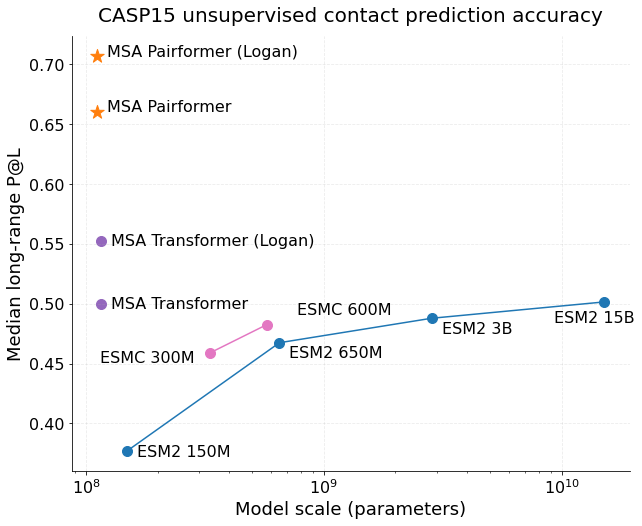

In [14]:
contact_type = "long_P@L"
agg_method = "median"
contact_type_name = "long_range"
print(f"\nGenerating scaling plot for {contact_type_name} with {agg_method} summarization:")
f, ax, pl_d = plot_scaling_figure(contact_type, agg_method)
f.savefig(f"results/scaling_plot_{contact_type_name}_{agg_method}.pdf", dpi=150)

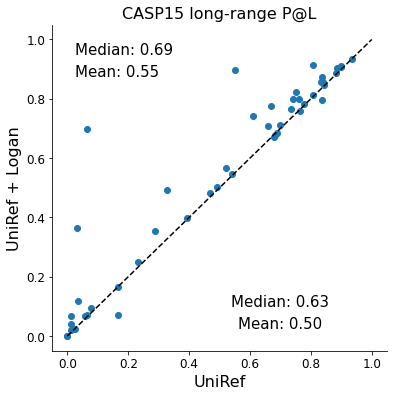

In [6]:
uniref_df = pd.read_csv("results/msa_pairformer/all_results.hhblits_uniref.tsv", sep='\t', index_col=0)
logan_df = pd.read_csv("results/msa_pairformer_logan/all_results.hhblits_uniref_mmseqs_logan.tsv", sep='\t', index_col=0)
plot_targets_l = [target_id for target_id in logan_df.index]
uniref_df = uniref_df.loc[plot_targets_l]
f, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(uniref_df.loc[uniref_df.index, "qba_long_P@L"], logan_df["qba_long_P@L"])
# Add 1:1 line
ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel("UniRef", size=16)
ax.set_ylabel("UniRef + Logan", size=16)
# Increase tick label size
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=12)
# Calculate statistics
uniref_median = np.median(uniref_df['qba_long_P@L'])
logan_median = np.median(logan_df['qba_long_P@L'])
uniref_mean = np.mean(uniref_df['qba_long_P@L'])
logan_mean = np.mean(logan_df['qba_long_P@L'])
# Add cleaner labels
ax.text(0.7, 0.1, f"Median: {uniref_median:.2f}", size=15, ha='center')
ax.text(0.025, 0.95, f"Median: {logan_median:.2f}", size=15, ha='left')
ax.text(0.7, 0.025, f"Mean: {uniref_mean:.2f}", size=15, ha='center')
ax.text(0.025, 0.875, f"Mean: {logan_mean:.2f}", size=15, ha='left')
ax.set_title("CASP15 long-range P@L", size=16)
# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

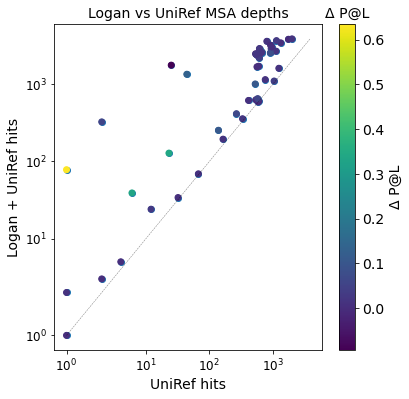

In [7]:
results_uniref_d = pickle.load(open("results/msa_pairformer/all_results.hhblits_uniref.pkl", "rb"))
results_logan_d = pickle.load(open("results/msa_pairformer_logan/all_results.hhblits_uniref_mmseqs_logan.pkl", "rb"))

logan_hits_d = {}
uniref_hits_d = {}
delta_precision_d = {}
for target in target_data_d:
    if target not in results_logan_d and target not in results_uniref_d:
        continue
    uniref_msa_file = target_data_d[target]["uniref_msa_file"]
    with open(uniref_msa_file, "r") as f:
        nSeqs = len([l for l in f.readlines() if l.startswith(">")])
    uniref_hits_d[target] = nSeqs
    # Logan MSA
    logan_msa_file = target_data_d[target]["logan_msa_file"]
    with open(logan_msa_file, "r") as f:
        logan_nSeqs = len([l for l in f.readlines() if l.startswith(">")])
    logan_hits_d[target] = logan_nSeqs
    delta_precision_d[target] = results_logan_d[target]['qba_eval_d']['long_P@L'] - results_uniref_d[target]['qba_eval_d']['long_P@L']
# Scatterplot of logan vs uniref hits (log scaled)
logan_hits_a = np.array(list(logan_hits_d.values()))
uniref_hits_a = np.array(list(uniref_hits_d.values()))
delta_precision_a = np.array(list(delta_precision_d.values()))
f, ax = plt.subplots(1, 1, figsize=(6,6))
ax.scatter(uniref_hits_a, logan_hits_a)
ax.set_xscale('symlog')
ax.set_yscale('symlog')
ax.set_xlabel('UniRef hits', size=14)
ax.set_ylabel('Logan + UniRef hits', size=14)
ax.set_title('Logan vs UniRef MSA depths', size=14)
# Add x = y line
min_val = min(uniref_hits_a.min(), logan_hits_a.min())
max_val = max(uniref_hits_a.max(), logan_hits_a.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, linewidth=0.5)
sc = ax.scatter(uniref_hits_a, logan_hits_a, c=delta_precision_a, cmap='viridis')
cbar = plt.colorbar(sc, ax=ax, label='Δ P@L', location='right')
cbar.ax.set_title('Δ P@L', fontsize=14)
cbar.set_label('')
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Δ P@L', fontsize=14)
ax.tick_params(axis='both', labelsize=12)

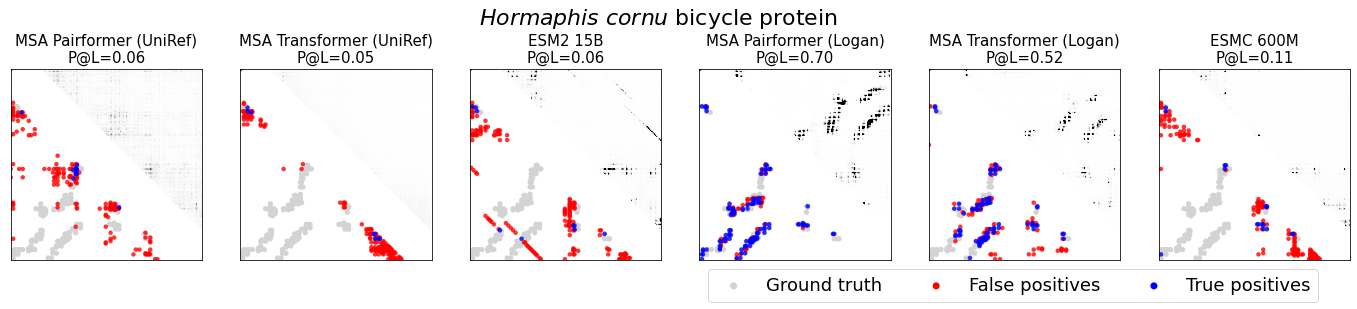

In [9]:
target_id = 'T1130'
contacts_a = target_data_d[target_id]["contacts_a"]
results_msatransformer_logan_d = pickle.load(open("results/msa_transformer_logan/msa_transformer_results.pkl", "rb"))
results_msatransformer_uniref_d = pickle.load(open("results/msa_transformer/msa_transformer_results.pkl", "rb"))
results_msapairformer_uniref_d = pickle.load(open("results/msa_pairformer/all_results.hhblits_uniref.pkl", "rb"))
results_msapairformer_logan_d = pickle.load(open("results/msa_pairformer_logan/all_results.hhblits_uniref_mmseqs_logan.pkl", "rb"))
results_esm_d = pickle.load(open("results/esm2_15B/esm2_15B_results.pkl", "rb"))
contacts_esmc_d = pickle.load(open("results/esmc_600m/all_pred_contacts_CASP15.pkl", "rb"))
results_esmc_d = pickle.load(open("results/esmc_600m/all_results_CASP15.pkl", "rb"))
predicted_contacts_l = [
    results_msapairformer_uniref_d[target_id]['monomer_qba_contacts_a'],
    results_msatransformer_uniref_d[target_id]['monomer_contacts_a'],
    results_esm_d[target_id]['monomer_contacts_a'],
    results_msapairformer_logan_d[target_id]['monomer_qba_contacts_a'],
    results_msatransformer_logan_d[target_id]['monomer_contacts_a'],
    contacts_esmc_d[target_id].float().cpu().numpy(),
]
f, ax = plt.subplots(1, 6, figsize=(24,4))
f.patch.set_facecolor('white')
ax = ax.ravel()
for i, predicted_contacts_a in enumerate(predicted_contacts_l):
    vmax = 0.4
    if i == 0:
        vmax = 0.1
    if i == 1:
        vmax = 0.3
    f, _ = plot_contact_map(
        [contacts_a, predicted_contacts_a],
        cutoffs = [None, None],
        minsep = 24,
        ss = [28, 20],
        cc =["lightgray","blue"],
        f=f,
        ax=ax[i],
        vmax=vmax
    )
ax[0].set_title(f"MSA Pairformer (UniRef)\nP@L={results_msapairformer_uniref_d[target_id]['qba_eval_d']['long_P@L']:.2f}", size=15)
ax[1].set_title(f"MSA Transformer (UniRef)\nP@L={results_msatransformer_uniref_d[target_id]['eval_d']['long_P@L']:.2f}", size=15)
ax[2].set_title(f"ESM2 15B\nP@L={results_esm_d[target_id]['eval_d']['long_P@L']:.2f}", size=15)
ax[3].set_title(f"MSA Pairformer (Logan)\nP@L={results_msapairformer_logan_d[target_id]['qba_eval_d']['long_P@L']:.2f}", size=15)
ax[4].set_title(f"MSA Transformer (Logan)\nP@L={results_msatransformer_logan_d[target_id]['eval_d']['long_P@L']:.2f}", size=15)
ax[5].set_title(f"ESMC 600M\nP@L={results_esmc_d[target_id]['long_P@L']:.2f}", size=15)
ax[3].legend(loc='upper left', bbox_to_anchor=(0, 0), fontsize=18, ncol=3)
f.suptitle("$\it{Hormaphis}$ $\it{cornu}$ bicycle protein", size=22, y=1.05)
f.savefig(f"results/hormaphis_cornu_bicycle_protein.pdf", bbox_inches='tight', dpi=150)


In [10]:
# Make supplementary table
results_files_d = {
    "MSA Pairformer": "results/msa_pairformer/all_results.hhblits_uniref.tsv",
    "MSA Pairformer (Logan)": "results/msa_pairformer_logan/all_results.hhblits_uniref_mmseqs_logan.tsv",
    "MSA Transformer": "results/msa_transformer/msa_transformer_results.tsv",
    "MSA Transformer (Logan)": "results/msa_transformer_logan/msa_transformer_results.tsv",
    "ESMC 600M": "results/esmc_600m/all_results_CASP15.tsv",
    "ESMC 300M": "results/esmc_300m/all_results_CASP15.tsv",
    "ESM2 15B": "results/esm2_15B/esm2_15B_results.tsv",
    "ESM2 3B": "results/esm2_3B/esm2_3B_results.tsv",
    "ESM2 650M": "results/esm2_650M/esm2_650M_results.tsv",
    "ESM2 300M": "results/esm2_3B/esm2_3B_results.tsv",
    "ESM2 150M": "results/esm2_150M/esm2_150M_results.tsv",
}
df_l = []
for method_name in results_files_d:
    cols = ['qba_long_P@L', 'qba_morethansix_P@L'] if "pairformer" in results_files_d[method_name] else ['long_P@L', 'morethansix_P@L']
    df = pd.read_csv(results_files_d[method_name], sep='\t', index_col=0)[cols]
    df.columns = [f"{method_name} ≥24", f"{method_name} ≥6"]
    df_l.append(df)
df = pd.concat(df_l, axis=1)
df.to_csv("results/CASP15_contact_predictions.tsv", sep='\t')
df.to_excel("results/CASP15_contact_predictions.xlsx")

df.head()

,MSA Pairformer ≥24,MSA Pairformer ≥6,MSA Pairformer (Logan) ≥24,MSA Pairformer (Logan) ≥6,MSA Transformer ≥24,MSA Transformer ≥6,MSA Transformer (Logan) ≥24,MSA Transformer (Logan) ≥6,ESMC 600M ≥24,ESMC 600M ≥6,...,ESM2 15B ≥24,ESM2 15B ≥6,ESM2 3B ≥24,ESM2 3B ≥6,ESM2 650M ≥24,ESM2 650M ≥6,ESM2 300M ≥24,ESM2 300M ≥6,ESM2 150M ≥24,ESM2 150M ≥6
T1146,0.806452,0.874552,0.813620,0.867384,0.641602,0.677246,0.659668,0.716797,0.457031,0.625000,...,0.458740,0.595215,0.523297,0.641577,0.462366,0.569892,0.523297,0.641577,0.304659,0.451613
T1181,0.165698,0.180233,0.071221,0.145349,0.313965,0.261719,0.075562,0.181641,0.679688,0.820312,...,0.687500,0.825684,0.688953,0.808140,0.677326,0.818314,0.688953,0.808140,0.671512,0.787791
T1179,0.539683,0.599206,0.547619,0.638889,0.456299,0.507812,0.464355,0.516113,0.027832,0.095215,...,0.019836,0.083313,0.039683,0.186508,0.027778,0.119048,0.039683,0.186508,0.027778,0.067460
T1130,0.062893,0.081761,0.698113,0.773585,0.050323,0.088074,0.521973,0.597656,0.113281,0.182617,...,0.056610,0.113220,0.088050,0.176101,0.100629,0.257862,0.088050,0.176101,0.088050,0.194969
T1132,0.836735,0.897959,0.795918,0.867347,0.663086,0.745117,0.673340,0.754883,0.664062,0.804688,...,0.734863,0.795898,0.693878,0.836735,0.724490,0.836735,0.693878,0.836735,0.673469,0.785714


In [11]:
# Make table that shows median and mean for long range and overall P@L

methods_order = [
    "MSA Pairformer (Logan)",
    "MSA Pairformer",
    "MSA Transformer",
    "MSA Transformer (Logan)",
    "ESMC 600M",
    "ESMC 300M",
    "ESM2 15B",
    "ESM2 650M",
    "ESM2 3B",
    "ESM2 150M"
]

# Remove any rows from df that have a NaN value
df_clean = df.dropna()

# Columns of the main df that correspond to each method for ≥24 (long-range) and all (overall)
method_to_long_col = {m: f"{m} ≥24" for m in methods_order}
method_to_all_col = {m: f"{m} ≥6" for m in methods_order}  # Use ≥6 as overall

summary_rows = []
for m in methods_order:
    # Make sure column exists in df_clean
    long_col = method_to_long_col[m]
    all_col = method_to_all_col[m]
    # Calculate median/mean, allowing for missing methods
    long_median = df_clean[long_col].median() if long_col in df_clean.columns else np.nan
    long_mean   = df_clean[long_col].mean() if long_col in df_clean.columns else np.nan
    all_median  = df_clean[all_col].median() if all_col in df_clean.columns else np.nan
    all_mean    = df_clean[all_col].mean() if all_col in df_clean.columns else np.nan
    summary_rows.append([long_median, long_mean, all_median, all_mean])

summary_df = pd.DataFrame(
    summary_rows, 
    index=methods_order,
    columns=["Long-range P@L (median)", "Long-range P@L (mean)", "Overall P@L (median)", "Overall P@L (mean)"]
)

# Write to Excel, as well as displaying the table
summary_df = summary_df.loc[['MSA Pairformer (Logan)', 'MSA Pairformer', 'MSA Transformer (Logan)', 'MSA Transformer', 'ESMC 600M', 'ESMC 300M', 'ESM2 15B', 'ESM2 3B', 'ESM2 650M', 'ESM2 150M']]
summary_df.to_excel("results/CASP15_contact_prediction_summary.xlsx")
summary_df

,Long-range P@L (median),Long-range P@L (mean),Overall P@L (median),Overall P@L (mean)
MSA Pairformer (Logan),0.706849,0.570838,0.801587,0.662183
MSA Pairformer,0.660274,0.518640,0.739130,0.604538
MSA Transformer (Logan),0.552734,0.467940,0.643066,0.566791
MSA Transformer,0.500000,0.439117,0.608398,0.532393
ESMC 600M,0.482422,0.427582,0.609375,0.535672
ESMC 300M,0.458984,0.398568,0.570312,0.509760
ESM2 15B,0.501465,0.458126,0.635742,0.575374
ESM2 3B,0.487805,0.445139,0.619178,0.557681
ESM2 650M,0.467391,0.422184,0.578082,0.537563
ESM2 150M,0.376682,0.344190,0.451613,0.455944
